In [109]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [110]:
#load data
df = pd.read_csv('/Users/beza/code/bezawitzyb/noshowshield/raw_data/hotel_bookings.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(20)

Dataset shape: 119,390 rows × 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.00,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.00,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.00,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.00,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.00,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22


In [111]:
# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

COLORS = {
    'cancelled': '#e74c3c',
    'completed': '#2ecc71',
    'primary': '#1a5276',
    'secondary': '#f39c12'
}
# Colour palette
C = {
    'red': '#e74c3c', 'green': '#2ecc71', 'blue': '#1a5276',
    'orange': '#f39c12', 'purple': '#8e44ad', 'teal': '#16a085',
    'grey': '#95a5a6'
}

In [112]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [113]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.00,NaN,NaN,NaN,0.37,0.48,0.00,0.00,0.00,1.00,1.00
lead_time,119390.00,NaN,NaN,NaN,104.01,106.86,0.00,18.00,69.00,160.00,737.00
arrival_date_year,119390.00,NaN,NaN,NaN,2016.16,0.71,2015.00,2016.00,2016.00,2017.00,2017.00
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.00,NaN,NaN,NaN,27.17,13.61,1.00,16.00,28.00,38.00,53.00
arrival_date_day_of_month,119390.00,NaN,NaN,NaN,15.80,8.78,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,119390.00,NaN,NaN,NaN,0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,119390.00,NaN,NaN,NaN,2.50,1.91,0.00,1.00,2.00,3.00,50.00
adults,119390.00,NaN,NaN,NaN,1.86,0.58,0.00,2.00,2.00,2.00,55.00


In [114]:
profile = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique(),
    'sample_value': df.iloc[0]
})
profile.sort_values('null_pct', ascending=False)

,dtype,non_null,null_count,null_pct,n_unique,sample_value
company,float64,6797,112593,94.31,352,NaN
agent,float64,103050,16340,13.69,333,NaN
country,object,118902,488,0.41,177,PRT
hotel,object,119390,0,0.00,2,Resort Hotel
previous_cancellations,int64,119390,0,0.00,15,0
reservation_status,object,119390,0,0.00,3,Check-Out
total_of_special_requests,int64,119390,0,0.00,6,0
required_car_parking_spaces,int64,119390,0,0.00,5,0
adr,float64,119390,0,0.00,8879,0.00
customer_type,object,119390,0,0.00,4,Transient


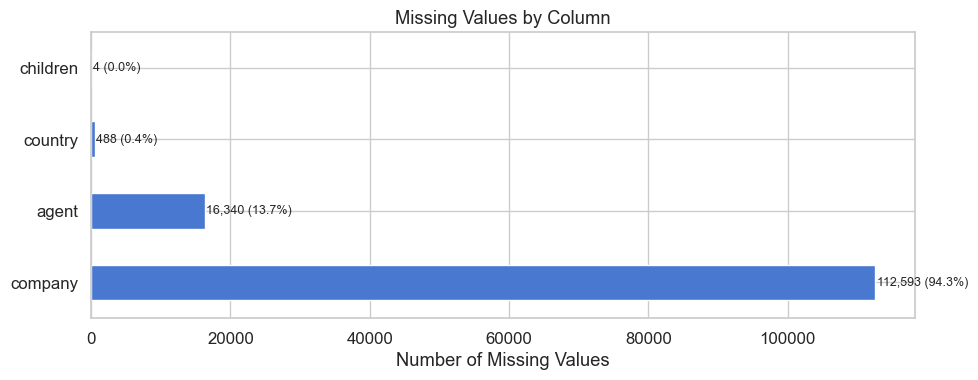

In [115]:
# Visualise missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.plot(kind='barh', ax=ax)
    ax.set_title('Missing Values by Column')
    ax.set_xlabel('Number of Missing Values')
    for i, v in enumerate(missing):
        ax.text(v + 200, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

In [116]:
df.duplicated().any()

np.True_

In [117]:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.00,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.00,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.00,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.00,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.00,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,0.00,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,0.00,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,0.00,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,0.00,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [118]:
df = df.drop_duplicates()

In [119]:
companies = df[df['company'].notna()]

In [120]:
companies.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,0.00,0,BB,FRA,Corporate,Corporate,0,0,0,A,G,0,No Deposit,NaN,110.00,0,Transient,107.42,0,0,Check-Out,2015-07-02
218,Resort Hotel,1,1,2015,July,28,8,0,1,2,0.00,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,110.00,0,Transient,104.72,0,1,Canceled,2015-07-08
220,Resort Hotel,0,1,2015,July,28,8,0,2,2,0.00,0,BB,CHE,Corporate,Corporate,0,0,0,A,F,0,No Deposit,NaN,110.00,0,Transient,104.72,1,1,Check-Out,2015-07-10
295,Resort Hotel,0,84,2015,July,28,11,1,1,2,0.00,0,HB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,113.00,0,Transient,100.00,1,0,Check-Out,2015-07-13
387,Resort Hotel,0,1,2015,July,29,14,0,1,1,0.00,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,270.00,0,Transient,134.00,0,0,Check-Out,2015-07-15
450,Resort Hotel,1,12,2015,July,29,16,2,3,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,E,E,0,No Deposit,NaN,178.00,0,Transient,139.00,0,0,Canceled,2015-07-07
541,Resort Hotel,0,0,2015,July,30,19,1,0,2,0.00,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,240.00,0,Group,88.20,0,0,Check-Out,2015-07-20
600,Resort Hotel,0,5,2015,July,30,21,0,2,1,0.00,0,BB,PRT,Corporate,Corporate,0,0,0,A,F,0,No Deposit,NaN,154.00,0,Transient,99.50,0,0,Check-Out,2015-07-23
628,Resort Hotel,1,19,2015,July,30,23,1,3,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,E,E,0,No Deposit,NaN,178.00,0,Transient,139.00,0,0,Canceled,2015-07-07
796,Resort Hotel,1,0,2015,July,31,30,0,1,1,0.00,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,270.00,0,Transient,114.00,0,0,Canceled,2015-07-30


In [121]:
# Handle missing values
# 'company' and 'agent' are often null — means no agent / no company (direct booking)
df['company'] = df['company'].fillna(0).astype(int)
df['agent'] = df['agent'].fillna(0).astype(int)

# 'country' — fill with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# 'children' — fill with 0
df['children'] = df['children'].fillna(0).astype(int)

print(f'Remaining nulls: {df.isnull().sum().sum()}')

Remaining nulls: 0


In [122]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394,0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9,0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9,0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89,0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [123]:
cancel_counts = df['is_canceled'].value_counts()
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'  Completed (0): {cancel_counts[0]:,} ({cancel_pct[0]:.1f}%)')
print(f'  Cancelled (1): {cancel_counts[1]:,} ({cancel_pct[1]:.1f}%)')
print(f'  Balance ratio: 1:{cancel_counts[0]/cancel_counts[1]:.2f}')

Class Distribution:
  Completed (0): 63,371 (72.5%)
  Cancelled (1): 24,025 (27.5%)
  Balance ratio: 1:2.64


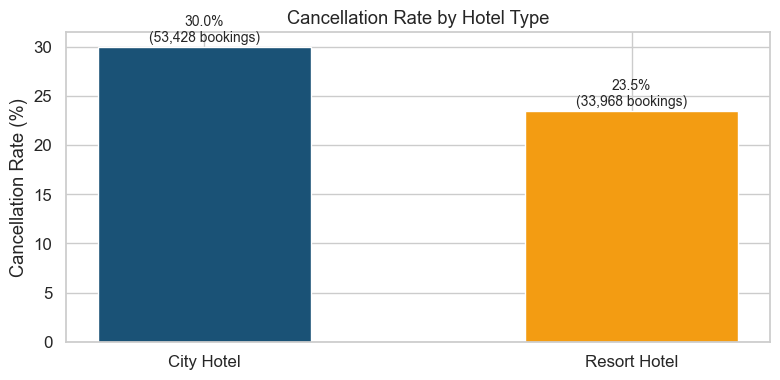

In [124]:
# Cancellation rate by hotel type
hotel_cancel = df.groupby('hotel')['is_canceled'].agg(['mean', 'count']).reset_index()
hotel_cancel.columns = ['hotel', 'cancel_rate', 'bookings']
hotel_cancel['cancel_rate'] = (hotel_cancel['cancel_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(hotel_cancel['hotel'], hotel_cancel['cancel_rate'],
              color=[COLORS['primary'], COLORS['secondary']], edgecolor='white', width=0.5)
ax.set_title('Cancellation Rate by Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
for bar, rate, count in zip(bars, hotel_cancel['cancel_rate'], hotel_cancel['bookings']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate}%\n({count:,} bookings)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

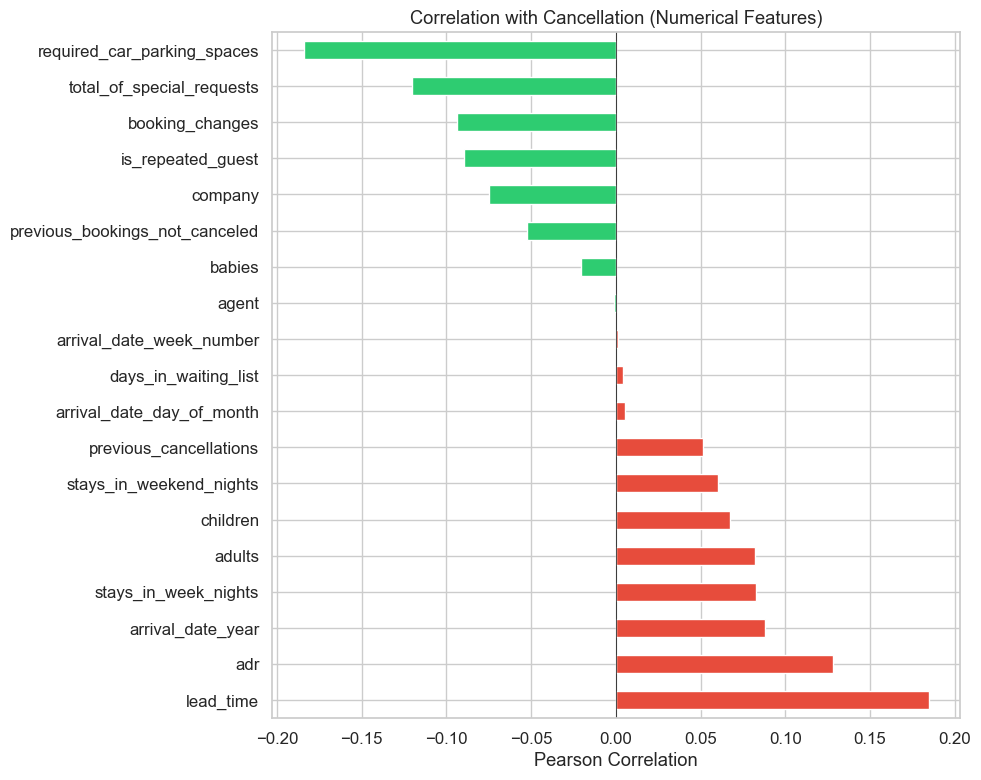

In [125]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numerical_cols].corr()['is_canceled'].drop('is_canceled').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_corr = [COLORS['cancelled'] if v > 0 else COLORS['completed'] for v in correlations]
correlations.plot(kind='barh', color=colors_corr, ax=ax, edgecolor='white')
ax.set_title('Correlation with Cancellation (Numerical Features)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [126]:
country_df= df.groupby('country')[[
    'booking_changes',
    'previous_bookings_not_canceled',
    'is_canceled'
]].sum().reset_index()

In [127]:
country_df['cancel_percentage'] = (
    country_df['is_canceled'] /
    (country_df['is_canceled'] + country_df['previous_bookings_not_canceled'])
) * 100

In [128]:
country_df.sort_values('is_canceled', ascending=False).head(50)

,country,booking_changes,previous_bookings_not_canceled,is_canceled,cancel_percentage
135,PRT,7362,14423,9791,40.44
59,GBR,3057,177,1985,91.81
51,ESP,1942,141,1862,92.96
56,FRA,2094,217,1733,88.87
81,ITA,855,58,1075,94.88
43,DEU,1242,37,1053,96.61
25,BRA,558,25,727,96.68
76,IRL,803,38,668,94.62
169,USA,649,12,459,97.45
15,BEL,485,24,411,94.48


In [135]:
country_df.sort_values('cancel_percentage', ascending=False).head(100)

,country,booking_changes,previous_bookings_not_canceled,is_canceled,cancel_percentage
86,KAZ,3,0,5,100.00
103,MAR,66,0,104,100.00
121,NGA,6,0,17,100.00
118,MYT,0,0,2,100.00
117,MYS,11,0,3,100.00
115,MUS,1,0,1,100.00
113,MOZ,35,0,17,100.00
112,MNE,1,0,2,100.00
110,MLT,3,0,5,100.00
108,MKD,7,0,2,100.00


In [130]:
country_df

,country,booking_changes,previous_bookings_not_canceled,is_canceled,cancel_percentage
0,ABW,0,0,0,NaN
1,AGO,135,32,193,85.78
2,AIA,0,0,0,NaN
3,ALB,3,0,2,100.00
4,AND,1,0,5,100.00
...,...,...,...,...,...
173,VGB,0,0,1,100.00
174,VNM,1,0,2,100.00
175,ZAF,22,1,29,96.67
176,ZMB,0,0,1,100.00


In [131]:
country_df.sort_values('booking_changes', ascending=False).head(100)

,country,booking_changes,previous_bookings_not_canceled,is_canceled,cancel_percentage
135,PRT,7362,14423,9791,40.44
59,GBR,3057,177,1985,91.81
56,FRA,2094,217,1733,88.87
51,ESP,1942,141,1862,92.96
43,DEU,1242,37,1053,96.61
81,ITA,855,58,1075,94.88
76,IRL,803,38,668,94.62
169,USA,649,12,459,97.45
123,NLD,573,28,350,92.59
25,BRA,558,25,727,96.68


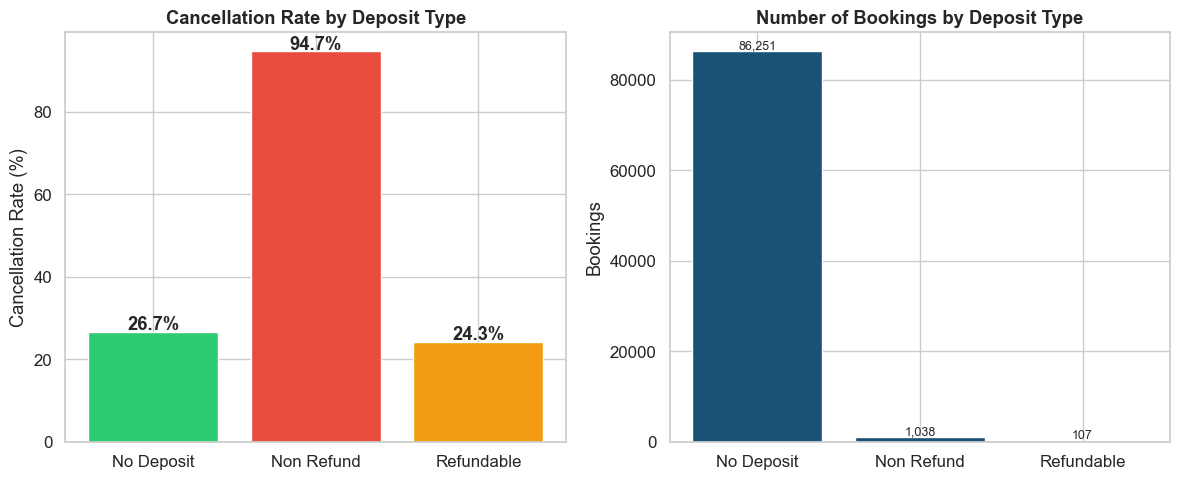

⚠️  Counter-intuitive: Non-Refundable deposits have the HIGHEST cancellation rate.
   Possible: price-sensitive customers who cancel when they find cheaper options,
   or bookings that are already expected to cancel (e.g., OTA block bookings).


In [133]:
deposit_stats = df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).reset_index()
deposit_stats.columns = ['deposit_type', 'cancel_rate', 'count']
deposit_stats['cancel_rate_pct'] = (deposit_stats['cancel_rate'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(deposit_stats['deposit_type'], deposit_stats['cancel_rate_pct'],
                   color=[C['green'], C['red'], C['orange']], edgecolor='white')
axes[0].set_title('Cancellation Rate by Deposit Type', fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
for bar, v in zip(bars, deposit_stats['cancel_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v}%', ha='center', fontweight='bold')

axes[1].bar(deposit_stats['deposit_type'], deposit_stats['count'],
            color=C['blue'], edgecolor='white')
axes[1].set_title('Number of Bookings by Deposit Type', fontweight='bold')
axes[1].set_ylabel('Bookings')
for i, v in enumerate(deposit_stats['count']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('⚠️  Counter-intuitive: Non-Refundable deposits have the HIGHEST cancellation rate.')
print('   Possible: price-sensitive customers who cancel when they find cheaper options,')
print('   or bookings that are already expected to cancel (e.g., OTA block bookings).')

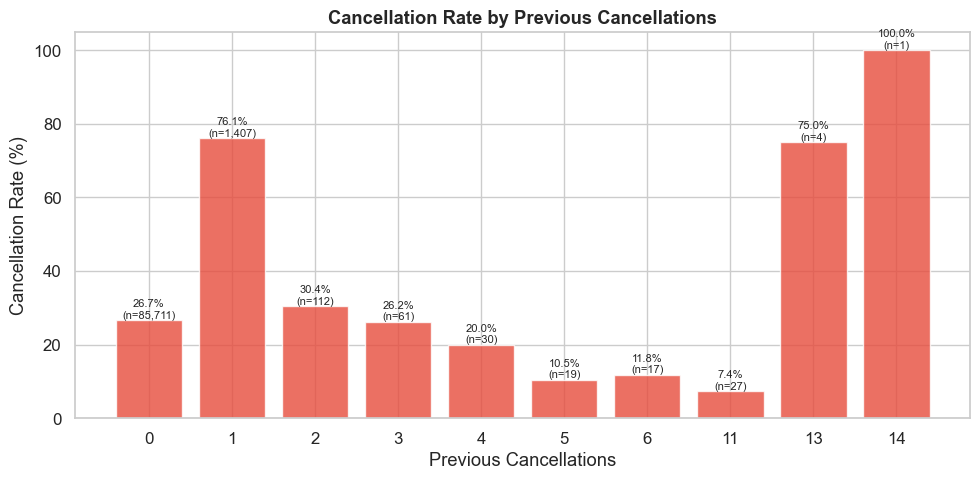

In [134]:
prev_cancel = df.groupby('previous_cancellations')['is_canceled'].agg(['mean', 'count']).reset_index()
prev_cancel.columns = ['prev_cancellations', 'cancel_rate', 'count']
display_df = prev_cancel.head(10).copy()
display_df['cancel_rate_pct'] = (display_df['cancel_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(display_df['prev_cancellations'].astype(str), display_df['cancel_rate_pct'],
              color=C['red'], alpha=0.8, edgecolor='white')
ax.set_title('Cancellation Rate by Previous Cancellations', fontweight='bold')
ax.set_xlabel('Previous Cancellations')
ax.set_ylabel('Cancellation Rate (%)')
for bar, rate, count in zip(bars, display_df['cancel_rate_pct'], display_df['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate}%\n(n={count:,})', ha='center', fontsize=8)
plt.tight_layout()
plt.show()